# Objectifs d'apprentissage – Semaine 9

À l'issue de cette semaine, l'étudiant sera capable de :

- **Distinguer** les filtres RIF (FIR) et RII (IIR) et leurs caractéristiques.
- **Concevoir** des filtres RIF par la méthode du fenêtrage.
- **Concevoir** des filtres RII par la méthode de la transformée bilinéaire (Butterworth, Chebyshev, Elliptique).
- **Analyser** la réponse fréquentielle (gain, phase) d'un filtre.
- **Visualiser** les pôles et zéros des filtres.
- **Choisir** le type de filtre (passe-bas, passe-haut, passe-bande, coupe-bande) en fonction des spécifications.
- **Utiliser** `scipy.signal` pour concevoir et appliquer des filtres numériques.
- **Évaluer** l'impact du filtrage sur un signal (réduction de bruit, extraction de composantes).

# 1. Rappels théoriques

## 1.1 Filtres RIF (FIR)

Les filtres à réponse impulsionnelle finie (RIF) ont une réponse impulsionnelle $h[n]$ de durée finie.

Équation aux différences :
$$ y[n] = \sum_{k=0}^{M} b_k \, x[n-k] $$

Propriétés :
- Toujours stables (si les coefficients sont finis).
- Peuvent avoir une phase linéaire (si les coefficients sont symétriques).
- Nécessitent un ordre généralement plus élevé que les RII pour des spécifications similaires.

**Méthodes de conception** :
- Fenêtrage (méthode simple) : troncature de la réponse impulsionnelle idéale multipliée par une fenêtre (Hamming, Hanning, etc.).
- Échantillonnage fréquentiel.
- Optimisation (Remez, moindres carrés).

## 1.2 Filtres RII (IIR)

Les filtres à réponse impulsionnelle infinie (RII) ont une réponse impulsionnelle de durée infinie.

Équation aux différences :
$$ \sum_{k=0}^{N} a_k \, y[n-k] = \sum_{k=0}^{M} b_k \, x[n-k] $$
avec $a_0 = 1$.

Propriétés :
- Peuvent être instables (pôles en dehors du cercle unité).
- Phase non linéaire en général.
- Ordre plus faible que les RIF pour les mêmes spécifications.

**Méthodes de conception** :
- Transformation bilinéaire à partir d'un filtre analogique (Butterworth, Chebyshev, Elliptique).
- Approximation par impulsion invariante.

## 1.3 Types de filtres fréquentiels

- **Passe-bas** : laisse passer les basses fréquences, atténue les hautes.
- **Passe-haut** : laisse passer les hautes fréquences, atténue les basses.
- **Passe-bande** : laisse passer une bande de fréquences.
- **Coupe-bande** : atténue une bande de fréquences (rejette).

---

# 2. Démonstrations Python

## 2.1 Conception d'un filtre RIF par fenêtrage

Nous allons concevoir un filtre passe-bas RIF en utilisant la méthode du fenêtrage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

print("Bibliothèques chargées.")

Bibliothèques chargées.


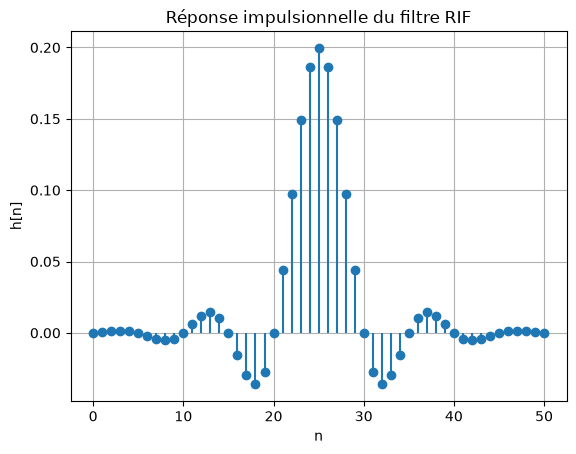

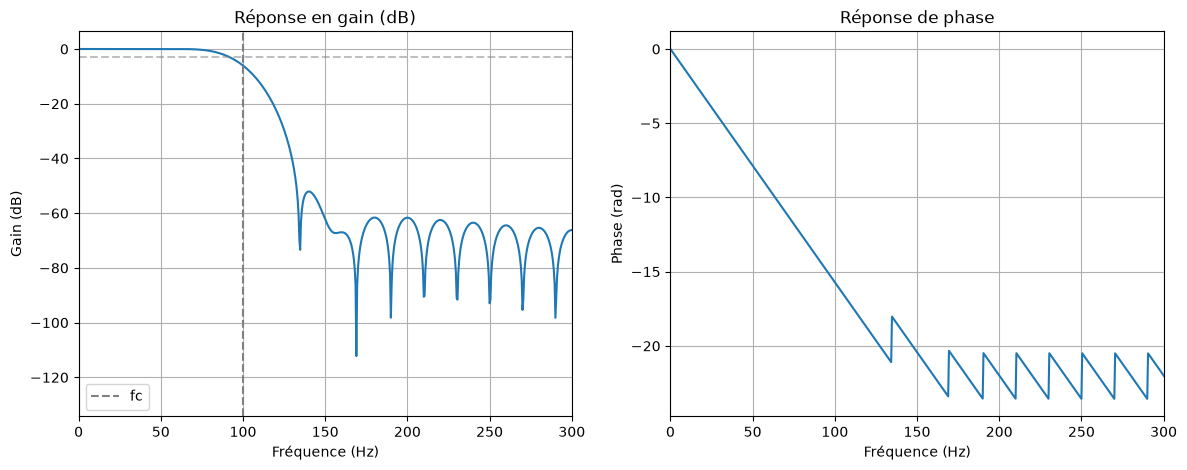

Les coefficients sont symétriques : True


In [2]:
# Paramètres du filtre
fs = 1000  # fréquence d'échantillonnage (Hz)
fc = 100   # fréquence de coupure (Hz)
N = 51     # nombre de coefficients (ordre M = N-1)

# Conception par fenêtrage de Hamming
b_fir = signal.firwin(N, fc, fs=fs, window='hamming', pass_zero='lowpass')

# Réponse impulsionnelle
n = np.arange(N)
plt.stem(n, b_fir, basefmt=' ')
plt.title('Réponse impulsionnelle du filtre RIF')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

# Réponse fréquentielle
w, H = signal.freqz(b_fir, a=1, worN=1024)
freqs = w * fs / (2 * np.pi)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, 20*np.log10(np.abs(H)))
plt.axvline(fc, color='gray', linestyle='--', label='fc')
plt.axhline(-3, color='gray', linestyle='--', alpha=0.5)
plt.title('Réponse en gain (dB)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Gain (dB)')
plt.xlim(0, 300)
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.unwrap(np.angle(H)))
plt.title('Réponse de phase')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (rad)')
plt.xlim(0, 300)
plt.grid()
plt.show()

# Vérification de la phase linéaire (pour RIF symétrique)
print("Les coefficients sont symétriques :", np.allclose(b_fir, b_fir[::-1]))

## 2.2 Conception d'un filtre RII (Butterworth)

Nous allons concevoir un filtre passe-bas RII de type Butterworth.

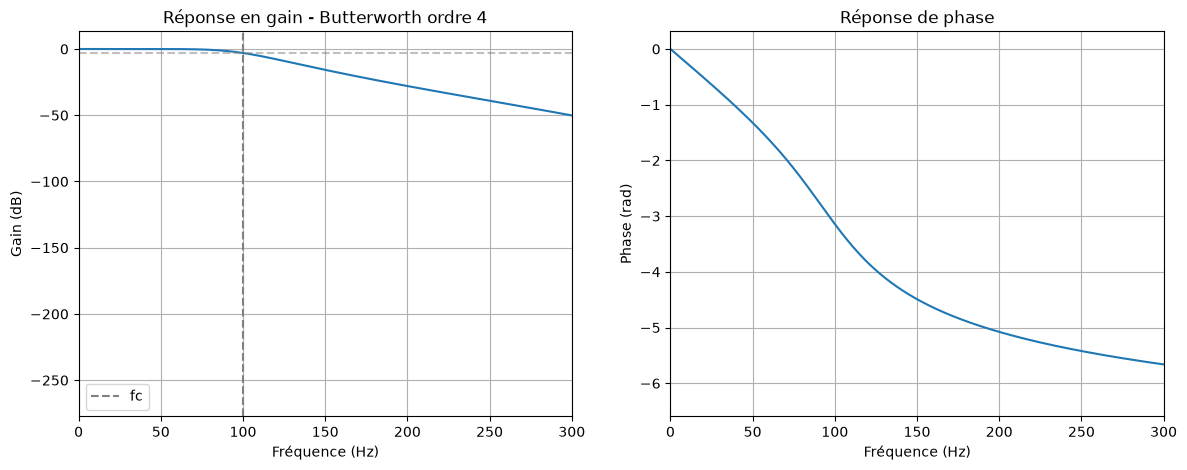

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


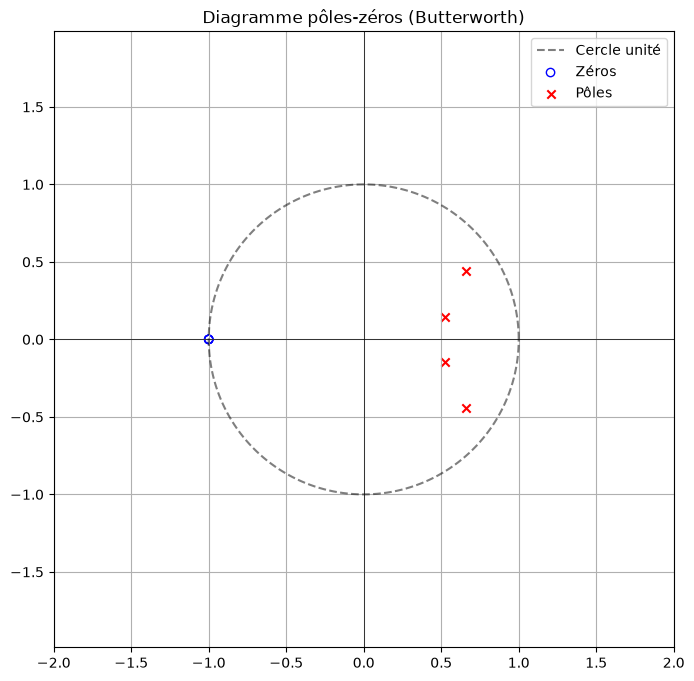

Système stable : True


In [3]:
order = 4
fc = 100
fs = 1000

# Conception
b_iir, a_iir = signal.butter(order, fc, fs=fs, btype='low')

# Réponse fréquentielle
w, H = signal.freqz(b_iir, a_iir, worN=1024)
freqs = w * fs / (2 * np.pi)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, 20*np.log10(np.abs(H)))
plt.axvline(fc, color='gray', linestyle='--', label='fc')
plt.axhline(-3, color='gray', linestyle='--', alpha=0.5)
plt.title('Réponse en gain - Butterworth ordre 4')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Gain (dB)')
plt.xlim(0, 300)
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.unwrap(np.angle(H)))
plt.title('Réponse de phase')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (rad)')
plt.xlim(0, 300)
plt.grid()
plt.show()

# Diagramme pôles-zéros
zeros, poles, gain = signal.tf2zpk(b_iir, a_iir)

plt.figure(figsize=(8, 8))
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label='Cercle unité')
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', facecolors='none', edgecolors='b', label='Zéros')
plt.scatter(np.real(poles), np.imag(poles), marker='x', color='r', label='Pôles')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.axis('equal')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.title('Diagramme pôles-zéros (Butterworth)')
plt.legend()
plt.show()

# Stabilité
stable = all(np.abs(p) < 1 for p in poles)
print(f"Système stable : {stable}")

## 2.3 Application à un signal bruité

Comparons les filtres RIF et RII sur un signal bruité.

In [ ]:
# Génération d'un signal propre + bruit
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
signal_clean = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*80*t)
bruit = 0.3 * np.random.randn(fs)
signal_noisy = signal_clean + bruit

# Filtres
fc = 60

# RIF (Hamming)
b_fir = signal.firwin(51, fc, fs=fs, window='hamming')

# RII (Butterworth, ordre 4)
b_iir, a_iir = signal.butter(4, fc, fs=fs, btype='low')

# Application
y_fir = signal.lfilter(b_fir, 1, signal_noisy)
y_iir = signal.lfilter(b_iir, a_iir, signal_noisy)

# Tracé
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t, signal_clean, label='Signal propre')
plt.title('Signal propre (50 Hz + 80 Hz)')
plt.legend()
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, signal_noisy, label='Signal bruité')
plt.title('Signal bruité')
plt.legend()
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, y_fir, label='Filtré RIF (Hamming)')
plt.title('Filtré RIF')
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, y_iir, label='Filtré RII (Butterworth)')
plt.title('Filtré RII')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# 3. Atelier : Comparaison RIF vs RII

Nous allons comparer les performances des filtres RIF et RII en termes d'ordre, de phase et de sélectivité.

In [ ]:
fc = 100  # Hz
fs = 1000

# RIF : différents ordres
orders_fir = [21, 51, 101]

plt.figure(figsize=(14, 6))
for i, N in enumerate(orders_fir):
    b = signal.firwin(N, fc, fs=fs, window='hamming')
    w, H = signal.freqz(b, a=1, worN=1024)
    freqs = w * fs / (2*np.pi)
    plt.subplot(1, 3, i+1)
    plt.plot(freqs, 20*np.log10(np.abs(H)))
    plt.title(f'RIF ordre {N-1}')
    plt.xlabel('Fréquence (Hz)')
    plt.ylabel('Gain (dB)')
    plt.xlim(0, 300)
    plt.ylim(-60, 5)
    plt.grid()
plt.suptitle('Effet de l\'ordre sur un RIF')
plt.tight_layout()
plt.show()

# RII : différents ordres
orders_iir = [2, 4, 8]

plt.figure(figsize=(14, 6))
for i, ordre in enumerate(orders_iir):
    b, a = signal.butter(ordre, fc, fs=fs, btype='low')
    w, H = signal.freqz(b, a, worN=1024)
    freqs = w * fs / (2*np.pi)
    plt.subplot(1, 3, i+1)
    plt.plot(freqs, 20*np.log10(np.abs(H)))
    plt.title(f'Butterworth ordre {ordre}')
    plt.xlabel('Fréquence (Hz)')
    plt.ylabel('Gain (dB)')
    plt.xlim(0, 300)
    plt.ylim(-60, 5)
    plt.grid()
plt.suptitle('Effet de l\'ordre sur un RII Butterworth')
plt.tight_layout()
plt.show()

# Comparaison de la phase
N = 51
b_fir = signal.firwin(N, fc, fs=fs, window='hamming')
b_iir, a_iir = signal.butter(8, fc, fs=fs, btype='low')

w, H_fir = signal.freqz(b_fir, a=1, worN=1024)
_, H_iir = signal.freqz(b_iir, a_iir, worN=1024)
freqs = w * fs / (2*np.pi)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, 20*np.log10(np.abs(H_fir)), label='RIF (N=51)')
plt.plot(freqs, 20*np.log10(np.abs(H_iir)), label='RII Butterworth ordre 8')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Gain (dB)')
plt.xlim(0, 300)
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.unwrap(np.angle(H_fir)), label='RIF (phase linéaire)')
plt.plot(freqs, np.unwrap(np.angle(H_iir)), label='RII (phase non linéaire)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (rad)')
plt.xlim(0, 300)
plt.legend()
plt.grid()
plt.show()

print("Le RIF a une phase linéaire (pas de distorsion de phase), le RII a une phase non linéaire.")

# 4. Exercices – Semaine 9

## Exercice 1 – Conception d'un filtre passe-haut RIF

1. Concevoir un filtre passe-haut RIF avec $f_c = 200$ Hz, $f_s = 1000$ Hz, ordre 30, fenêtre de Hamming.
2. Tracer la réponse impulsionnelle, le gain et la phase.
3. Appliquer ce filtre à un signal composé de sinusoïdes à 50 Hz, 150 Hz, 250 Hz. Observer la sortie.

**Code** :

In [ ]:
# À compléter
fs = 1000
fc = 200
N = 30

# Conception passe-haut
b = signal.firwin(N, fc, fs=fs, window='hamming', pass_zero='highpass')

# Tracé de la réponse
w, H = signal.freqz(b, a=1, worN=1024)
freqs = w * fs / (2*np.pi)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, 20*np.log10(np.abs(H)))
plt.title('Passe-haut RIF')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 500)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.unwrap(np.angle(H)))
plt.title('Phase')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 500)
plt.grid()
plt.show()

# Test sur un signal
t = np.linspace(0, 0.1, int(0.1*fs), endpoint=False)
x = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*150*t) + np.sin(2*np.pi*250*t)
y = signal.lfilter(b, 1, x)

plt.plot(t, x, label='Entrée')
plt.plot(t, y, label='Sortie')
plt.legend()
plt.grid()
plt.show()

## Exercice 2 – Filtre RII passe-bande (Chebyshev type I)

1. Concevoir un filtre passe-bande RII de type Chebyshev-I avec les spécifications :
   - Bande passante : 100-200 Hz
   - Ondulation dans la bande passante : 1 dB
   - Fréquence d'échantillonnage : 1000 Hz
   - Ordre minimal.
2. Tracer la réponse en gain, la phase, et le diagramme pôles-zéros.
3. Appliquer le filtre à un signal contenant 50 Hz, 150 Hz et 300 Hz. Commenter.

**Code** :

In [ ]:
fs = 1000
Wp = [100, 200]  # bande passante (Hz)
Wp_norm = [Wp[0]/(fs/2), Wp[1]/(fs/2)]
rp = 1  # ondulation en dB

# Conception
order, wn = signal.cheb1ord(Wp_norm, [Wp_norm[0]*0.8, Wp_norm[1]*1.2], rp, 40)
b, a = signal.cheby1(order, rp, wn, btype='bandpass')
print(f"Ordre : {order}")

w, H = signal.freqz(b, a, worN=1024)
freqs = w * fs / (2*np.pi)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, 20*np.log10(np.abs(H)))
plt.axvline(100, color='gray', linestyle='--')
plt.axvline(200, color='gray', linestyle='--')
plt.title('Chebyshev-I passe-bande')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 400)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.unwrap(np.angle(H)))
plt.title('Phase')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 400)
plt.grid()
plt.show()

# Test
t = np.linspace(0, 0.1, int(0.1*fs), endpoint=False)
x = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*150*t) + np.sin(2*np.pi*300*t)
y = signal.lfilter(b, a, x)

plt.plot(t, x, label='Entrée')
plt.plot(t, y, label='Sortie')
plt.legend()
plt.grid()
plt.show()

## Exercice 3 – Comparaison de filtres pour un même gabarit

Soit un gabarit de filtre passe-bas :
- Fréquence de coupure : 100 Hz
- Atténuation minimale de 40 dB dans la bande stop à partir de 150 Hz.
- Ondulation en bande passante : 0.5 dB (pour les RII).

1. Concevoir un RIF (Hamming) répondant à ce gabarit (trouver l'ordre nécessaire).
2. Concevoir un RII (Butterworth) répondant à ce gabarit (trouver l'ordre).
3. Comparer les ordres, les réponses en gain et la phase.
4. Quel filtre choisiriez-vous pour une application audio ? Pour une application temps réel ?

**Code** :

In [ ]:
fs = 1000
fc = 100
f_stop = 150
att_stop = 40  # dB

# RIF : ordre estimé par la formule de Kaiser
delta = 10**(-att_stop/20)
A = -20*np.log10(delta)
if A > 21:
    D = (A - 7.95) / 14.36
else:
    D = 0.922
N_est = int(np.ceil(D * 2 * fs / (f_stop - fc)))
print(f"Ordre RIF estimé : {N_est}")

b_fir = signal.firwin(N_est, fc, fs=fs, window=('kaiser', A))

# RII : Butterworth
order_iir = signal.buttord(fc/(fs/2), f_stop/(fs/2), 0.5, att_stop)
b_iir, a_iir = signal.butter(order_iir, fc/(fs/2), btype='low')
print(f"Ordre RII Butterworth : {order_iir}")

# Tracé
w, H_fir = signal.freqz(b_fir, a=1, worN=1024)
_, H_iir = signal.freqz(b_iir, a_iir, worN=1024)
freqs = w * fs / (2*np.pi)

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(freqs, 20*np.log10(np.abs(H_fir)), label=f'RIF (ordre {N_est})')
plt.plot(freqs, 20*np.log10(np.abs(H_iir)), label=f'RII (ordre {order_iir})')
plt.axvline(fc, color='gray', linestyle='--')
plt.axvline(f_stop, color='gray', linestyle='--')
plt.axhline(-att_stop, color='gray', linestyle='--')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Gain (dB)')
plt.xlim(0, 250)
plt.ylim(-60, 5)
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(freqs, np.unwrap(np.angle(H_fir)), label='RIF (phase linéaire)')
plt.plot(freqs, np.unwrap(np.angle(H_iir)), label='RII (phase non linéaire)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (rad)')
plt.xlim(0, 250)
plt.legend()
plt.grid()
plt.show()

# Application audio : phase linéaire importante -> RIF.
# Temps réel : RII plus efficace (ordre plus faible).

## Exercice 4 – Filtre coupe-bande (notch) pour éliminer 50 Hz

1. Concevoir un filtre coupe-bande (notch) de type RII (Butterworth ou Chebyshev) pour supprimer 50 Hz.
   - Largeur de bande : 5 Hz.
   - Fréquence d'échantillonnage : 1000 Hz.
2. Appliquer ce filtre à un signal contenant une sinusoïde à 50 Hz et d'autres fréquences.
3. Observer l'effet sur le signal et son spectre.

**Code** :

In [ ]:
fs = 1000
f0 = 50
Q = f0 / 5  # facteur de qualité

# Notch avec iirnotch (filtre à réjection)
b, a = signal.iirnotch(f0, Q, fs)

w, H = signal.freqz(b, a, worN=1024)
freqs = w * fs / (2*np.pi)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, 20*np.log10(np.abs(H)))
plt.axvline(f0, color='gray', linestyle='--')
plt.title('Filtre coupe-bande (notch) à 50 Hz')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 100)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.unwrap(np.angle(H)))
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 100)
plt.grid()
plt.show()

# Test
t = np.linspace(0, 0.2, int(0.2*fs), endpoint=False)
x = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)
y = signal.lfilter(b, a, x)

plt.plot(t, x, label='Entrée (50 Hz + 120 Hz)')
plt.plot(t, y, label='Sortie (50 Hz atténué)')
plt.legend()
plt.grid()
plt.show()

# Spectre
X = np.fft.fft(x)
Y = np.fft.fft(y)
freqs_fft = np.fft.fftfreq(len(x), 1/fs)[:len(x)//2]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs_fft, np.abs(X[:len(x)//2]) / len(x))
plt.title('Spectre entrée')
plt.xlim(0, 150)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs_fft, np.abs(Y[:len(x)//2]) / len(x))
plt.title('Spectre sortie (50 Hz supprimé)')
plt.xlim(0, 150)
plt.grid()
plt.show()

## Exercice 5 – Analyse de la réponse impulsionnelle et de la stabilité

Pour un filtre RII donné (par exemple Butterworth ordre 2, fc=0.1), calculer :
1. La réponse impulsionnelle (utiliser `signal.impulse`).
2. La réponse indicielle (entrée échelon).
3. Vérifier la stabilité en traçant les pôles.
4. Modifier l'ordre ou la fréquence de coupure pour observer l'influence sur la stabilité.

**Code** :

In [ ]:
fs = 1000
fc = 100

for order in [2, 4, 6]:
    b, a = signal.butter(order, fc, fs=fs, btype='low')
    
    # Réponse impulsionnelle
    n, h = signal.impulse((b, a, 1/fs), N=50)
    
    # Pôles
    zeros, poles, gain = signal.tf2zpk(b, a)
    
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 3, 1)
    plt.stem(n, h, basefmt=' ')
    plt.title(f'Réponse impulsionnelle (ordre {order})')
    plt.grid()
    
    plt.subplot(1, 3, 2)
    plt.scatter(np.real(poles), np.imag(poles), marker='x', color='r')
    theta = np.linspace(0, 2*np.pi, 200)
    plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    plt.axis('equal')
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.title('Pôles')
    plt.grid()
    
    # Réponse indicielle
    t = np.linspace(0, 0.1, 100)
    t, y_step = signal.step((b, a, 1/fs), T=t)
    plt.subplot(1, 3, 3)
    plt.plot(t, y_step)
    plt.title('Réponse indicielle')
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    
    stable = all(np.abs(p) < 1 for p in poles)
    print(f"Ordre {order} : stable = {stable}")

# 5. Livrable Semaine 9

- Remplir les cellules de code avec vos solutions.
- Répondre aux questions théoriques dans les cellules markdown.
- Inclure des commentaires explicatifs.
- Rendre le notebook complet (cellules exécutées).

**Date de rendu** : à définir par l'enseignant.

---